In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gauravaggarwal0911","key":"ccfb853b5120f29f68c6697bcea80973"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mohammadamireshraghi/blood-cell-cancer-all-4class
!unzip -q blood-cell-cancer-all-4class.zip -d /content/all_dataset

Dataset URL: https://www.kaggle.com/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 1.68G/1.68G [00:13<00:00, 135MB/s] 



In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_ROOT = "/content/drive/MyDrive/research"

print("Checking dataset root:", DATASET_ROOT)
print("Root exists:", os.path.exists(DATASET_ROOT))

for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)
    image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]

    if image_files:
        print(f"{sub_indent}Images found: {len(image_files)}")
        print(f"{sub_indent}Example: {image_files[:3]}")

    if level >= 4:
        dirs[:] = []

Checking dataset root: /content/drive/MyDrive/research
Root exists: True
research/


In [ ]:
import os
import pandas as pd

DATASET_ROOT = "/content/all_dataset"

image_paths = []
labels = []

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith(valid_extensions):
            path = os.path.join(root, file)

            # Use full folder path, not only immediate folder name
            full_path_lower = path.lower()

            # Label mapping for ALL 4-class dataset
            if "benign" in full_path_lower:
                label = 0

            elif (
                "early" in full_path_lower
                or "pre" in full_path_lower
                or "pro" in full_path_lower
                or "malignant" in full_path_lower
            ):
                label = 1

            else:
                print("Skipped:", path)
                continue

            image_paths.append(path)
            labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.head())
print(df["label"].value_counts())
print("Total images:", len(df))

print("\nClass meaning:")
print("0 = Benign / Normal")
print("1 = Malignant / Cancer")

                                          image_path  label
0  /content/all_dataset/Blood cell Cancer [ALL]/[...      1
1  /content/all_dataset/Blood cell Cancer [ALL]/[...      1
2  /content/all_dataset/Blood cell Cancer [ALL]/[...      1
3  /content/all_dataset/Blood cell Cancer [ALL]/[...      1
4  /content/all_dataset/Blood cell Cancer [ALL]/[...      1
label
1    2730
0     512
Name: count, dtype: int64
Total images: 3242

Class meaning:
0 = Benign / Normal
1 = Malignant / Cancer


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

SEED = 42

# 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Train distribution:
label
1    1911
0     358
Name: count, dtype: int64

Validation distribution:
label
1    409
0     77
Name: count, dtype: int64

Test distribution:
label
1    410
0     77
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 60
AUTOTUNE = tf.data.AUTOTUNE

RESULT_DIR = "/content/drive/MyDrive/research"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder created:", RESULT_DIR)

Result folder created: /content/drive/MyDrive/research


In [ ]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label


augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15)
], name="cell_augmentation")


def augment_image(image, label):
    image = augmentation(image, training=True)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Data pipeline created successfully.")

Data pipeline created successfully.


In [ ]:
classes = np.unique(train_df["label"])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(cls): weight for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:", class_weights)

Class weights: {0: np.float64(3.1689944134078214), 1: np.float64(0.5936682365253794)}


In [ ]:
def se_block(x, ratio=8):
    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)

    x = layers.Multiply()([x, se])
    return x


def residual_attention_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)

    x = se_block(x, ratio=8)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal"
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("swish")(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)

    return x


def build_bm_ra_cnn(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)

    # Initial stem block
    x = layers.Conv2D(
        32,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    # Stage 1
    x = residual_attention_block(x, 32, stride=1, dropout_rate=0.05)
    x = residual_attention_block(x, 32, stride=1, dropout_rate=0.05)

    # Stage 2
    x = residual_attention_block(x, 64, stride=2, dropout_rate=0.10)
    x = residual_attention_block(x, 64, stride=1, dropout_rate=0.10)

    # Stage 3
    x = residual_attention_block(x, 128, stride=2, dropout_rate=0.15)
    x = residual_attention_block(x, 128, stride=1, dropout_rate=0.15)

    # Stage 4
    x = residual_attention_block(x, 256, stride=2, dropout_rate=0.20)
    x = residual_attention_block(x, 256, stride=1, dropout_rate=0.20)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.45)(x)

    x = layers.Dense(
        64,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="BM_RA_CNN")
    return model


model = build_bm_ra_cnn(input_shape=(224, 224, 3))
model.summary()

Model: "BM_RA_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      9,216 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ multiply[0][0],   │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 224, 224,  │          0 │ activation_2[0][… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │      9,216 │ spatial_dropout2

 Total params: 2,927,769 (11.17 MB)

 Trainable params: 2,922,457 (11.15 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
best_model_path = os.path.join(RESULT_DIR, "best_BM_RA_CNN.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5888 - auc: 0.6756 - loss: 0.6895 - precision: 0.9097 - recall: 0.5667   
Epoch 1: val_auc improved from None to 0.44224, saving model to /content/drive/MyDrive/research/best_BM_RA_CNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/research/best_BM_RA_CNN.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6924 - auc: 0.8167 - loss: 0.5729 - precision: 0.9450 - recall: 0.6740 - val_accuracy: 0.8416 - val_auc: 0.4422 - val_loss: 0.5849 - val_precision: 0.8416 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/60
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8363 - auc: 0.9312 - loss: 0.3747 - precision: 0.9777 - recall: 0.8259
Epoch 2: val_auc improved from 0.44224 to 0.44966, saving model to /content/drive/MyDrive/research/best_BM_RA_CNN.keras

Epoch 2: finished saving model to /content/drive/MyDrive/research/best_BM_RA_CNN.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8660 

In [ ]:
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(RESULT_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

Training history saved at: /content/drive/MyDrive/research/training_history.csv


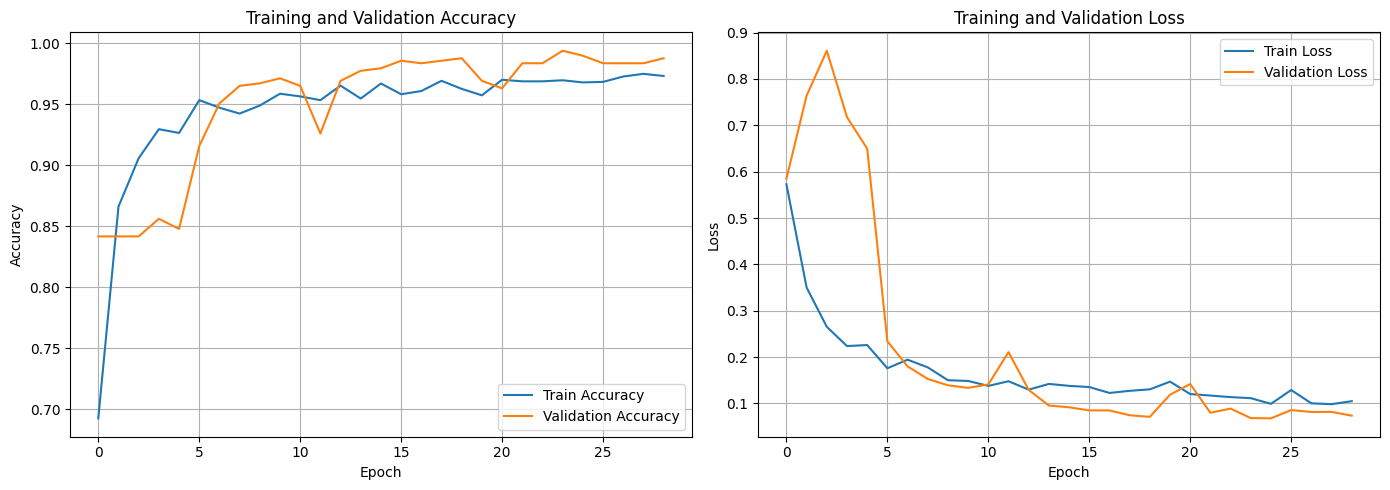

Accuracy/loss curves saved at: /content/drive/MyDrive/research/accuracy_loss_curves.png


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

curve_path = os.path.join(RESULT_DIR, "accuracy_loss_curves.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy/loss curves saved at:", curve_path)

In [ ]:
best_model = keras.models.load_model(best_model_path)

test_results = best_model.evaluate(test_ds)

print("Test Results:")
for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 454ms/step - accuracy: 0.9856 - auc: 0.9987 - loss: 0.0724 - precision: 0.9975 - recall: 0.9854
Test Results:
loss: 0.0724
compile_metrics: 0.9856


In [ ]:
y_true = []
y_prob = []
test_image_paths = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_prob.extend(preds.ravel())
    y_true.extend(labels.numpy().ravel())

# Keep image paths separately from test_df
test_image_paths = test_df["image_path"].values

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Default threshold
y_pred = (y_prob >= 0.5).astype(int)

print("Prediction completed.")

Prediction completed.


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc_score = roc_auc_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

metrics_dict = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "AUC": auc_score
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_csv_path = os.path.join(RESULT_DIR, "test_metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=False)

print(metrics_df)
print("Test metrics saved at:", metrics_csv_path)

   Accuracy  Precision  Recall/Sensitivity  Specificity  F1-score       AUC
0  0.985626   0.997531            0.985366     0.987013  0.991411  0.998828
Test metrics saved at: /content/drive/MyDrive/research/test_metrics.csv


In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_csv_path = os.path.join(RESULT_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path)

print(report_df)
print("Classification report saved at:", report_csv_path)

              precision    recall  f1-score     support
Benign         0.926829  0.987013  0.955975   77.000000
Malignant      0.997531  0.985366  0.991411  410.000000
accuracy       0.985626  0.985626  0.985626    0.985626
macro avg      0.962180  0.986189  0.973693  487.000000
weighted avg   0.986352  0.985626  0.985808  487.000000
Classification report saved at: /content/drive/MyDrive/research/classification_report.csv


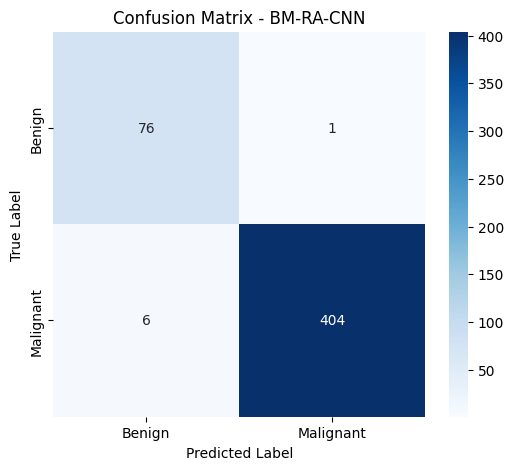

Confusion matrix CSV saved at: /content/drive/MyDrive/research/confusion_matrix.csv
Confusion matrix image saved at: /content/drive/MyDrive/research/confusion_matrix.png


In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual_Benign", "Actual_Malignant"],
    columns=["Predicted_Benign", "Predicted_Malignant"]
)

cm_csv_path = os.path.join(RESULT_DIR, "confusion_matrix.csv")
cm_df.to_csv(cm_csv_path)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BM-RA-CNN")

cm_png_path = os.path.join(RESULT_DIR, "confusion_matrix.png")
plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix CSV saved at:", cm_csv_path)
print("Confusion matrix image saved at:", cm_png_path)

In [ ]:
best_threshold = 0.5
best_f1 = 0

threshold_records = []

for threshold in np.arange(0.10, 0.90, 0.01):
    temp_pred = (y_prob >= threshold).astype(int)

    temp_accuracy = accuracy_score(y_true, temp_pred)
    temp_precision = precision_score(y_true, temp_pred, zero_division=0)
    temp_recall = recall_score(y_true, temp_pred, zero_division=0)
    temp_f1 = f1_score(y_true, temp_pred, zero_division=0)

    threshold_records.append({
        "threshold": threshold,
        "accuracy": temp_accuracy,
        "precision": temp_precision,
        "recall": temp_recall,
        "f1_score": temp_f1
    })

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_threshold = threshold

threshold_df = pd.DataFrame(threshold_records)
threshold_csv_path = os.path.join(RESULT_DIR, "threshold_tuning_results.csv")
threshold_df.to_csv(threshold_csv_path, index=False)

print("Best threshold:", best_threshold)
print("Best F1-score:", best_f1)
print("Threshold tuning saved at:", threshold_csv_path)

Best threshold: 0.14999999999999997
Best F1-score: 0.9939098660170523
Threshold tuning saved at: /content/drive/MyDrive/research/threshold_tuning_results.csv


In [ ]:
y_pred_best = (y_prob >= best_threshold).astype(int)

best_report_dict = classification_report(
    y_true,
    y_pred_best,
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

best_report_df = pd.DataFrame(best_report_dict).transpose()

best_report_csv_path = os.path.join(RESULT_DIR, "classification_report_best_threshold.csv")
best_report_df.to_csv(best_report_csv_path)

print(best_report_df)
print("Best threshold classification report saved at:", best_report_csv_path)

              precision    recall  f1-score     support
Benign         0.973684  0.961039  0.967320   77.000000
Malignant      0.992701  0.995122  0.993910  410.000000
accuracy       0.989733  0.989733  0.989733    0.989733
macro avg      0.983192  0.978080  0.980615  487.000000
weighted avg   0.989694  0.989733  0.989706  487.000000
Best threshold classification report saved at: /content/drive/MyDrive/research/classification_report_best_threshold.csv


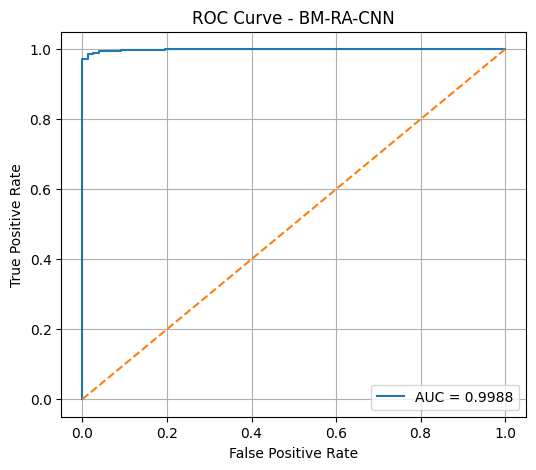

ROC curve image saved at: /content/drive/MyDrive/research/roc_curve.png
ROC values saved at: /content/drive/MyDrive/research/roc_curve_values.csv


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_df = pd.DataFrame({
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
    "threshold": thresholds
})

roc_csv_path = os.path.join(RESULT_DIR, "roc_curve_values.csv")
roc_df.to_csv(roc_csv_path, index=False)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BM-RA-CNN")
plt.legend()
plt.grid(True)

roc_png_path = os.path.join(RESULT_DIR, "roc_curve.png")
plt.savefig(roc_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("ROC curve image saved at:", roc_png_path)
print("ROC values saved at:", roc_csv_path)

In [ ]:
prediction_df = pd.DataFrame({
    "image_path": test_image_paths,
    "true_label": y_true,
    "predicted_probability": y_prob,
    "predicted_label_default_threshold": y_pred,
    "predicted_label_best_threshold": y_pred_best
})

prediction_csv_path = os.path.join(RESULT_DIR, "test_predictions.csv")
prediction_df.to_csv(prediction_csv_path, index=False)

print(prediction_df.head())
print("Prediction results saved at:", prediction_csv_path)

                                          image_path  true_label  \
0  /content/all_dataset/Blood cell Cancer [ALL]/[...           1   
1  /content/all_dataset/Blood cell Cancer [ALL]/B...           0   
2  /content/all_dataset/Blood cell Cancer [ALL]/[...           1   
3  /content/all_dataset/Blood cell Cancer [ALL]/B...           0   
4  /content/all_dataset/Blood cell Cancer [ALL]/[...           1   

   predicted_probability  predicted_label_default_threshold  \
0               0.998479                                  1   
1               0.000024                                  0   
2               0.999993                                  1   
3               0.000025                                  0   
4               0.999999                                  1   

   predicted_label_best_threshold  
0                               1  
1                               0  
2                               1  
3                               0  
4                               

In [ ]:
final_model_path = os.path.join(RESULT_DIR, "final_BM_RA_CNN_model.keras")
best_model.save(final_model_path)

print("Best model saved at:", best_model_path)
print("Final model saved at:", final_model_path)

Best model saved at: /content/drive/MyDrive/research/best_BM_RA_CNN.keras
Final model saved at: /content/drive/MyDrive/research/final_BM_RA_CNN_model.keras


In [ ]:
import shutil

zip_path = "/content/drive/MyDrive/research/BM_RA_CNN_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/content/drive/MyDrive/research/BM_RA_CNN_results",
    format="zip",
    root_dir=RESULT_DIR
)

print("All results zipped at:", zip_path)

RuntimeError: File size too large, try using force_zip64